<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Flower_Classification_CNN_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

#Load the dataset

In [3]:
#Load Dataset
(ds_train,ds_val,ds_test),info=tfds.load(
    'tf_flowers',
    split=['train[:70%]','train[70%:85%]','train[85%:]'],
    as_supervised=True,
    with_info=True
)
NUM_CLASSES=info.features['label'].num_classes
CLASS_NAMES=info.features['label'].names



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.RPAM9V_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [4]:
CLASS_NAMES

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

#Preprocessing the dataset

In [5]:
IMG_SIZE=224
BATCH_SIZE=32

def preprocess(image,label):
  image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))
  image=tf.keras.applications.mobilenet_v2.preprocess_input(image)
  return image,label

train_ds=ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE)
val_ds=ds_val.map(preprocess).batch(BATCH_SIZE)
test_ds=ds_test.map(preprocess).batch(BATCH_SIZE)

#Data Augementation

In [6]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)

])

#Creating the basemodel

In [7]:
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable=False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Build the sequential model

In [10]:
from tensorflow.keras import models
from tensorflow.keras.layers import Dense,Flatten,Dropout,GlobalAveragePooling2D



In [12]:
model=models.Sequential()
#Adding augmentation
model.add(data_augmentation)
#Adding Base model
model.add(base_model)

#Add classification head
model.add(GlobalAveragePooling2D())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(NUM_CLASSES,activation='softmax'))
#

In [13]:
model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [15]:
history=model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.7443 - loss: 0.7065 - val_accuracy: 0.8113 - val_loss: 0.4711
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.8482 - loss: 0.3970 - val_accuracy: 0.8475 - val_loss: 0.4156
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8809 - loss: 0.3238 - val_accuracy: 0.8893 - val_loss: 0.3273
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8891 - loss: 0.3000 - val_accuracy: 0.8802 - val_loss: 0.3445
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.9046 - loss: 0.2674 - val_accuracy: 0.8766 - val_loss: 0.3350
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9031 - loss: 0.2729 - val_accuracy: 0.8802 - val_loss: 0.3124
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.9163 - loss: 0.2280 - val_accuracy: 0.8893 - val_loss: 0.3087
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9202 - loss: 0.2088 - val_accuracy: 0.8911 

#Fine tuning the model

🎯 Simple Summary

👉 Phase 1: Train only new layers while freezing pretrained model

👉 Phase 2: Unfreeze top layers and fine-tune with a low learning rate

In [18]:
base_model.trainable=True

for layers in base_model.layers[:-30]:
  layers.trainable=False

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(1e-5),
    metrics=['accuracy']
)

In [19]:
history2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds
)

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 0.8139 - loss: 0.6503 - val_accuracy: 0.8893 - val_loss: 0.5328
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.8871 - loss: 0.3499 - val_accuracy: 0.8838 - val_loss: 0.5713
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9085 - loss: 0.2588 - val_accuracy: 0.8875 - val_loss: 0.5563
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9148 - loss: 0.2465 - val_accuracy: 0.9002 - val_loss: 0.5373
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9206 - loss: 0.2230 - val_accuracy: 0.9074 - val_loss: 0.5168
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9303 - loss: 0.1959 - val_accuracy: 0.9111 - val_loss: 0.5014
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.9338 - loss: 0.1863 - val_accuracy: 0.9093 - val_loss: 0.4595
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.9428 - loss: 0.1591 - val_accuracy: 0

#Evaluating

In [20]:
loss,acc=model.evaluate(test_ds)
print("Model Accuracy: ",acc )

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9255 - loss: 0.3186
Model Accuracy:  0.9254545569419861


In [21]:
def show_predictions(data):
  images, labels = next(iter(data))
  preds=model.predict(images)
  pred_labels=np.argmax(preds,axis=1)
  print(preds)
  print(pred_labels)

show_predictions(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[8.72332633e-01 1.49225201e-02 7.13028619e-03 5.92097822e-05
  1.05555370e-01]
 [9.99992490e-01 5.08331027e-07 1.76919968e-09 6.98270651e-06
  1.03137623e-10]
 [9.99976873e-01 3.43790667e-08 6.12373885e-09 2.31560334e-05
  1.14728822e-08]
 [2.65997158e-09 3.89151182e-08 9.54715431e-01 2.12671325e-09
  4.52846289e-02]
 [1.06633227e-11 1.42955764e-06 9.99987245e-01 4.43366162e-08
  1.13281130e-05]
 [6.33443946e-08 9.99999046e-01 4.93003771e-09 5.06049291e-09
  8.44127328e-07]
 [7.28053468e-12 1.00000000e+00 2.10892697e-12 1.66402499e-11
  6.34932995e-10]
 [1.68080194e-04 8.46414478e-05 2.47719795e-01 1.52110285e-03
  7.50506401e-01]
 [1.48976669e-01 8.49042117e-05 7.20593607e-06 8.50922048e-01
  9.26472057e-06]
 [4.01431215e-11 4.56906084e-12 9.24680124e-11 1.00000000e+00
  3.19868992e-10]
 [3.63425414e-08 4.56325643e-06 9.99994993e-01 3.04154838e-07
  5.20728882e-08]
 [9.99056280e-01 9.26290959e-05 1.27155784e-06 9.55185242e-05
  7.54281471e-04]
 [1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


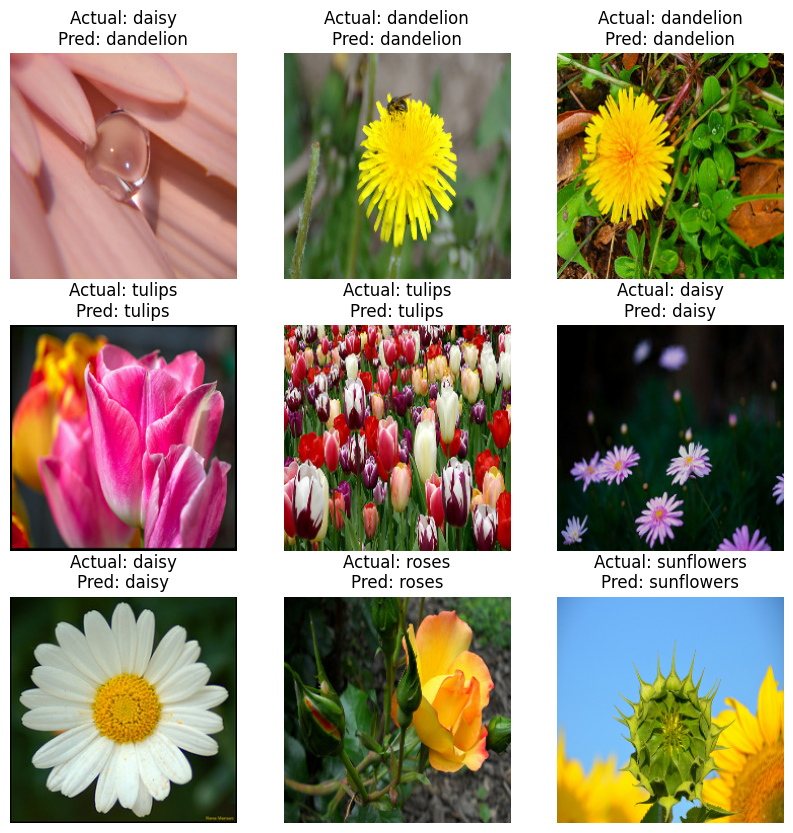

In [26]:
def show_predictions_p(dataset):
    images, labels = next(iter(dataset))
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow((images[i] + 1) / 2)  # fix display
        plt.title(
            f"Actual: {CLASS_NAMES[labels[i]]}\n"
            f"Pred: {CLASS_NAMES[pred_labels[i]]}"
        )

        plt.axis('off')
    plt.show()

show_predictions_p(test_ds)